<a href="https://colab.research.google.com/github/VijaiyWorld/ML_AI/blob/main/Final_E_commerce_Customer_Segmentation_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Import Required Library***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,silhouette_score

In [ ]:
df = pd.read_csv('E-Com_Project1.csv', encoding="ISO-8859-1")

In [ ]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.dropna(subset=["Description","CustomerID"],inplace=True)

In [ ]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
df.duplicated().sum()

5225

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

0

In [ ]:
def check_columns_greater_than_zero(column_name):
  if(df[column_name].le(0)).any():
    return df[df[column_name] > 0]
  return df

In [ ]:
df = check_columns_greater_than_zero("Quantity")
df = check_columns_greater_than_zero("UnitPrice")
df = check_columns_greater_than_zero("CustomerID")


In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"],format="mixed")

In [ ]:
df['total'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
df_total_sales_by_country = df.groupby('Country')['total'].sum().sort_values(ascending=False)

In [ ]:
df_total_sales_by_country

,total
Country,
United Kingdom,6767873.394
Netherlands,284661.540
EIRE,250285.220
Germany,221698.210
France,196712.840
Australia,137077.270
Switzerland,55739.400
Spain,54774.580
Belgium,40910.960


<ipython-input-16-671fdca077db>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.index, y=top_10_countries.values,palette='viridis')


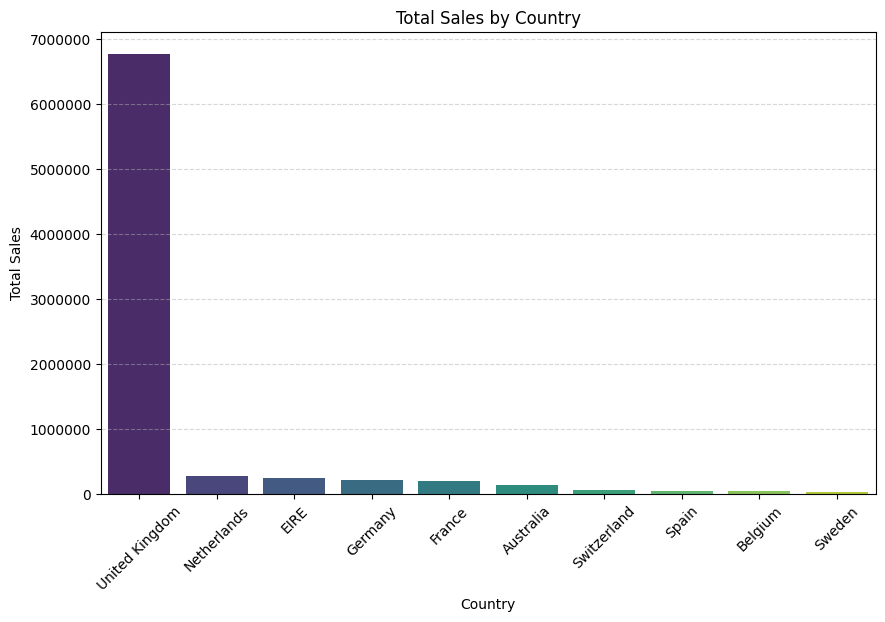

In [ ]:
top_10_countries = df_total_sales_by_country.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values,palette='viridis')
plt.xticks(rotation=45)
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.title('Total Sales by Country')
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.ticklabel_format(style='plain', axis='y')


In [ ]:
df_top_sold_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)

In [ ]:
df_top_sold_products.head(10)

,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,53215
JUMBO BAG RED RETROSPOT,45066
ASSORTED COLOUR BIRD ORNAMENT,35314
WHITE HANGING HEART T-LIGHT HOLDER,34147
PACK OF 72 RETROSPOT CAKE CASES,33409
POPCORN HOLDER,30504
RABBIT NIGHT LIGHT,27094
MINI PAINT SET VINTAGE,25880
PACK OF 12 LONDON TISSUES,25321


<ipython-input-19-3955e832b35b>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_25_sold_products.index, y=top_25_sold_products.values,palette='magma')


Text(0, 0.5, 'Quantity')

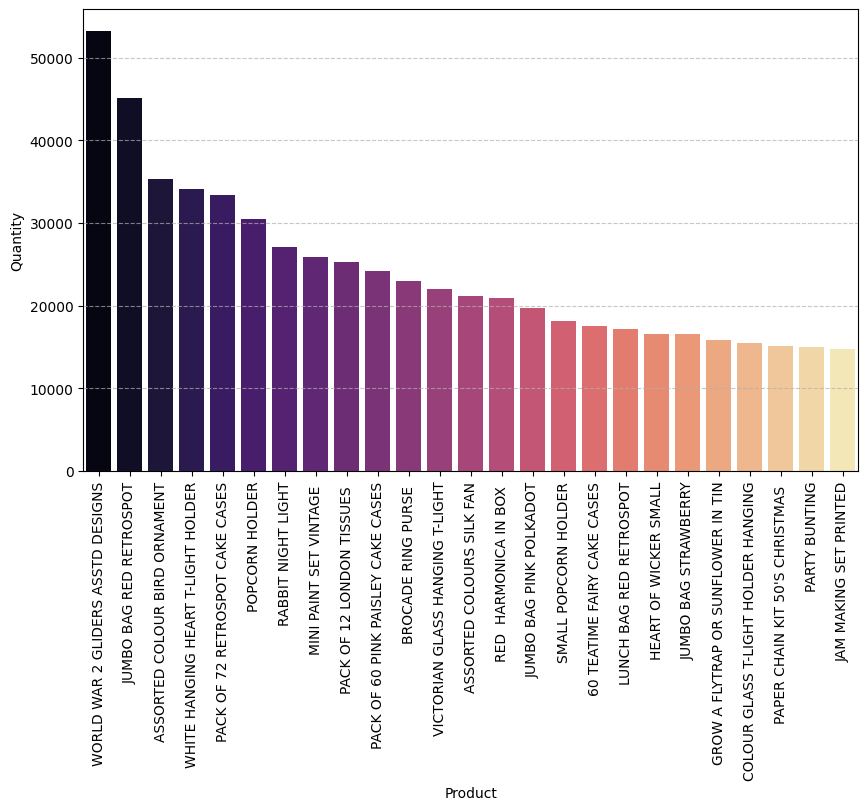

In [ ]:
top_25_sold_products = df_top_sold_products.head(25)

plt.figure(figsize=(10,6))
sns.barplot(x=top_25_sold_products.index, y=top_25_sold_products.values,palette='magma')
plt.xticks(rotation=90)
plt.xlabel('Product')
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.ylabel('Quantity')

In [ ]:
df_countrywise_most_sold_products = df.groupby(["Country","Description"])["Quantity"].sum().sort_values(ascending=False)

In [ ]:
df_countrywise_most_sold_products.head()

Country         Description                       
United Kingdom  PAPER CRAFT , LITTLE BIRDIE           80995
                MEDIUM CERAMIC TOP STORAGE JAR        76919
                WORLD WAR 2 GLIDERS ASSTD DESIGNS     49086
                JUMBO BAG RED RETROSPOT               41878
                WHITE HANGING HEART T-LIGHT HOLDER    34630
Name: Quantity, dtype: int64

In [ ]:
top_10_countrywise_most_sold_products = df_countrywise_most_sold_products.head(10)

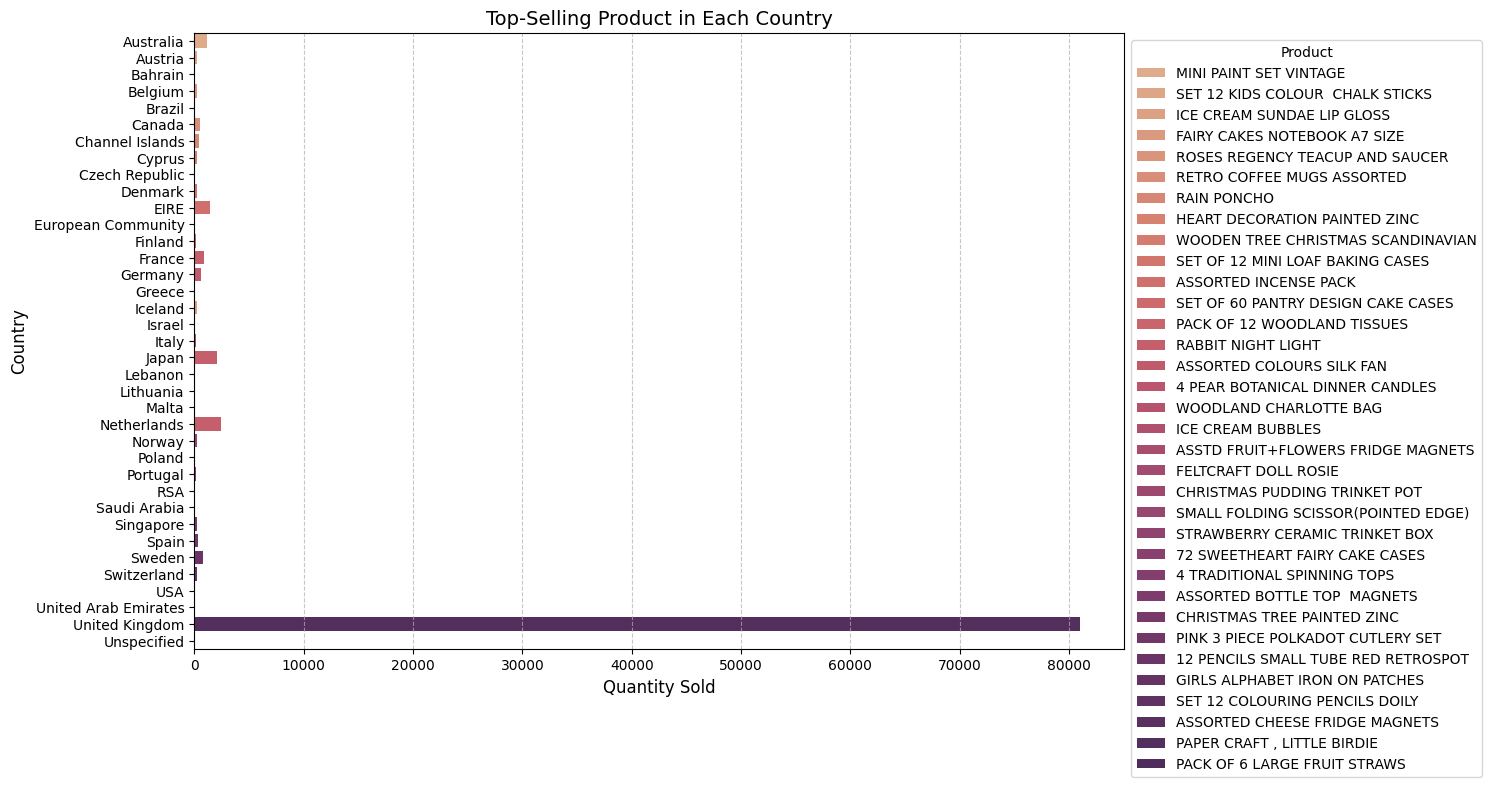

In [ ]:


# Get top-selling product per country
df_top_products = df.loc[df.groupby("Country")["Quantity"].idxmax()]

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
sns.barplot(
    y=df_top_products["Country"],
    x=df_top_products["Quantity"],
    hue=df_top_products["Description"],
    dodge=False,  # Ensures only one bar per country
    palette="flare"
)

# Labels and Formatting
plt.xlabel("Quantity Sold", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.title("Top-Selling Product in Each Country", fontsize=14)
plt.legend(title="Product", bbox_to_anchor=(1,1), loc="upper left")
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()


In [ ]:
df["YearMonth"] = pd.to_datetime(df['InvoiceDate']).dt.to_period('M')
df["YearMonth"]

NameError: name 'pd' is not defined

In [ ]:
monthlysales = df.groupby("YearMonth")["total"].sum()
monthlysales

,total
YearMonth,
2010-12,570422.730
2011-01,568101.310
2011-02,446084.920
2011-03,594081.760
2011-04,468374.331
2011-05,677355.150
2011-06,660046.050
2011-07,598962.901
2011-08,644051.040


In [ ]:
monthlysales

,total
YearMonth,
2010-12,570422.730
2011-01,568101.310
2011-02,446084.920
2011-03,594081.760
2011-04,468374.331
2011-05,677355.150
2011-06,660046.050
2011-07,598962.901
2011-08,644051.040


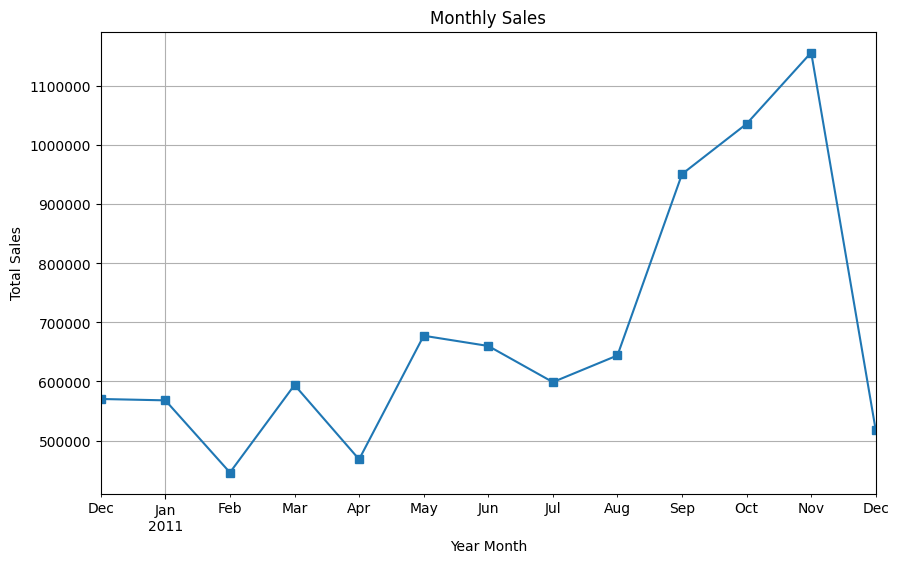

In [ ]:
plt.figure(figsize=(10,6))
monthlysales.plot(marker="s")
plt.xlabel("Year Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()


In [ ]:
df_top_sold_products_month_wise = df.loc[df.groupby("YearMonth")["Quantity"].idxmax()]

In [ ]:
df_top_sold_products_month_wise

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total,YearMonth
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,2010-12-02 17:38:00,0.18,16754.0,United Kingdom,518.40,2010-12
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60,2011-01
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087.0,United Kingdom,3202.92,2011-02
125282,547037,21967,PACK OF 12 SKULL TISSUES,2160,2011-03-20 10:37:00,0.25,14101.0,United Kingdom,540.00,2011-03
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,6539.40,2011-04
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom,3096.00,2011-05
221722,556267,16216,LETTER SHAPE PENCIL SHARPENER,1600,2011-06-09 19:33:00,0.06,13694.0,United Kingdom,96.00,2011-06
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609.0,United Kingdom,191.16,2011-07
291249,562439,84879,ASSORTED COLOUR BIRD ORNAMENT,2880,2011-08-04 18:06:00,1.45,12931.0,United Kingdom,4176.00,2011-08
348317,567423,23288,GREEN VINTAGE SPOT BEAKER,1944,2011-09-20 11:05:00,1.08,17450.0,United Kingdom,2099.52,2011-09


Text(0.5, 1.0, 'Top-Selling Product in Each Month')

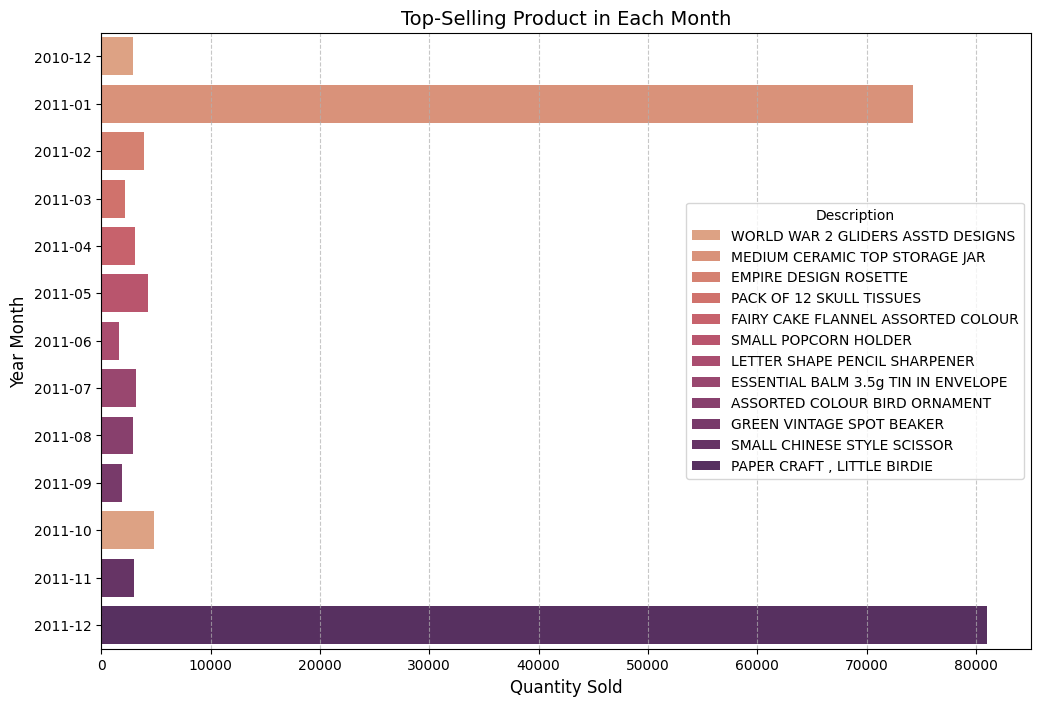

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(
    y=df_top_sold_products_month_wise["YearMonth"],
    x=df_top_sold_products_month_wise["Quantity"],
    hue=df_top_sold_products_month_wise["Description"],
    dodge=False,  # Ensures only one bar per country
    palette="flare"
)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.xlabel("Quantity Sold", fontsize=12)
plt.ylabel("Year Month", fontsize=12)
plt.title("Top-Selling Product in Each Month", fontsize=14)



### ***Calculate RFM***

In [ ]:
last_purchased_date = df.groupby("CustomerID")["InvoiceDate"].max()
rfm = (df["InvoiceDate"].max() - last_purchased_date).dt.days.reset_index()

In [ ]:
rfm.rename(columns={"InvoiceDate":"Recency"},inplace=True)


In [ ]:
total_purchase_by_customer = df.groupby("CustomerID")["total"].sum().reset_index()


In [ ]:
total_purchase_by_customer

,CustomerID,total
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4333,18280.0,180.60
4334,18281.0,80.82
4335,18282.0,178.05
4336,18283.0,2045.53


In [ ]:
rfm = rfm.merge(total_purchase_by_customer,on="CustomerID",how="left")

In [ ]:
rfm.rename(columns={"total":"Monetary"},inplace=True)

In [ ]:
rfm

,CustomerID,Recency,Monetary
0,12346.0,325,77183.60
1,12347.0,1,4310.00
2,12348.0,74,1797.24
3,12349.0,18,1757.55
4,12350.0,309,334.40
...,...,...,...
4333,18280.0,277,180.60
4334,18281.0,180,80.82
4335,18282.0,7,178.05
4336,18283.0,3,2045.53


In [ ]:
purchase_frequency = df.groupby("CustomerID")["InvoiceNo"].count().reset_index()
purchase_frequency.rename(columns={"InvoiceNo":"Frequency"},inplace=True)

In [ ]:
purchase_frequency

,CustomerID,Frequency
0,12346.0,1
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17
...,...,...
4333,18280.0,10
4334,18281.0,7
4335,18282.0,12
4336,18283.0,721


In [ ]:
rfm = rfm.merge(purchase_frequency,on="CustomerID",how="left")

In [ ]:
rfm

,CustomerID,Recency,Monetary,Frequency
0,12346.0,325,77183.60,1
1,12347.0,1,4310.00,182
2,12348.0,74,1797.24,31
3,12349.0,18,1757.55,73
4,12350.0,309,334.40,17
...,...,...,...,...
4333,18280.0,277,180.60,10
4334,18281.0,180,80.82,7
4335,18282.0,7,178.05,12
4336,18283.0,3,2045.53,721


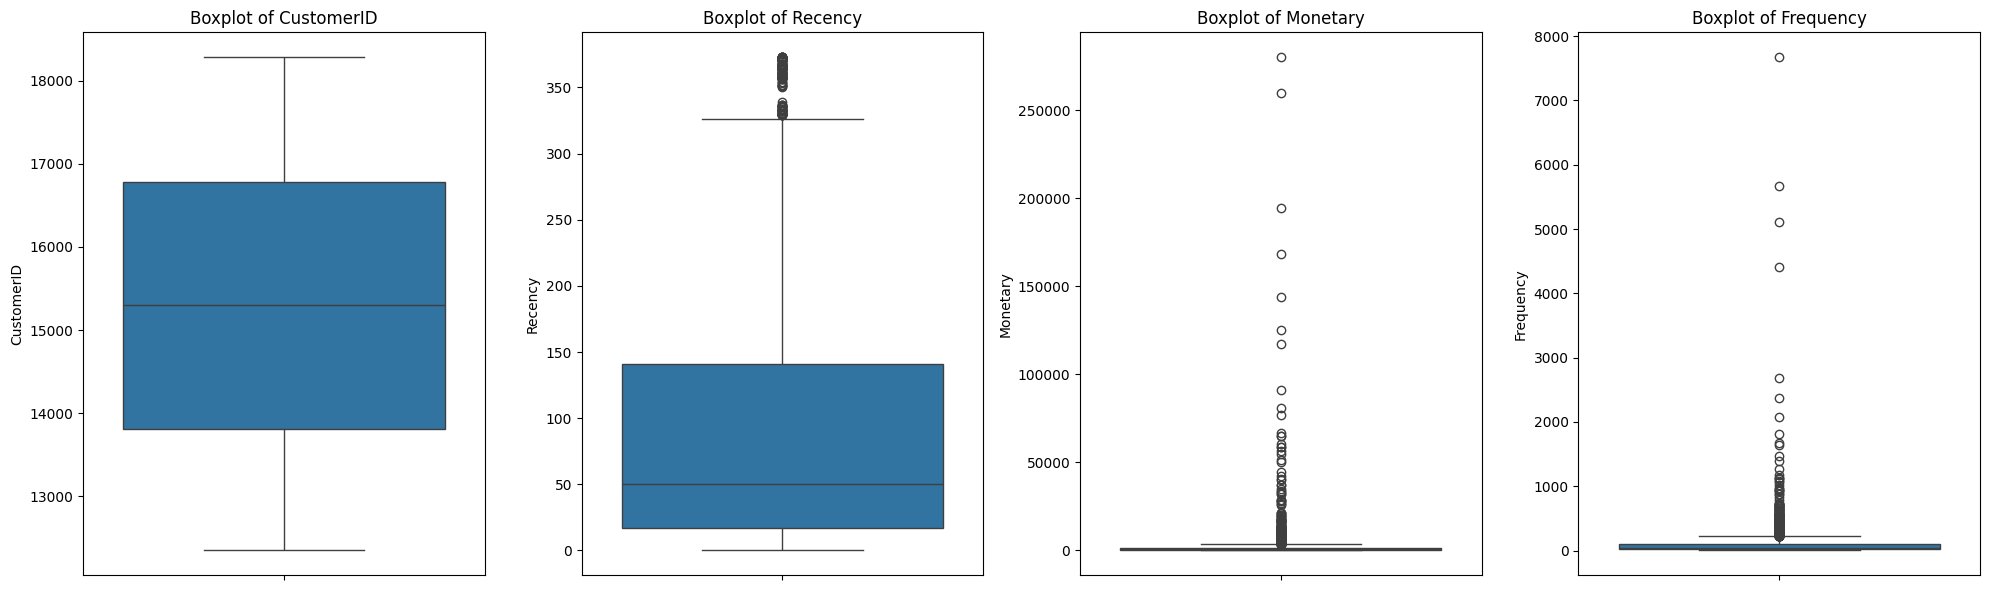

In [ ]:
# Number of columns in the dataset
num_cols = len(rfm.columns)

# Create subplots with a dynamic layout
plt.figure(figsize=(5 * num_cols, 6))  # Adjust figure size based on the number of columns
for i, col in enumerate(rfm.columns, 1):
    plt.subplot(1, num_cols, i)  # Adjust subplot layout
    sns.boxplot(y=rfm[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

In [ ]:
# Compute Q1 and Q3 for each RFM column
Q1 = rfm[['Recency', 'Frequency', 'Monetary']].quantile(0.25)
Q3 = rfm[['Recency', 'Frequency', 'Monetary']].quantile(0.75)
IQR = Q3 - Q1

# Define outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Ensure proper alignment and remove outliers
rfm_cleaned = rfm[
    ~((rfm[['Recency', 'Frequency', 'Monetary']] < lower_bound) |
      (rfm[['Recency', 'Frequency', 'Monetary']] > upper_bound)).any(axis=1)
]


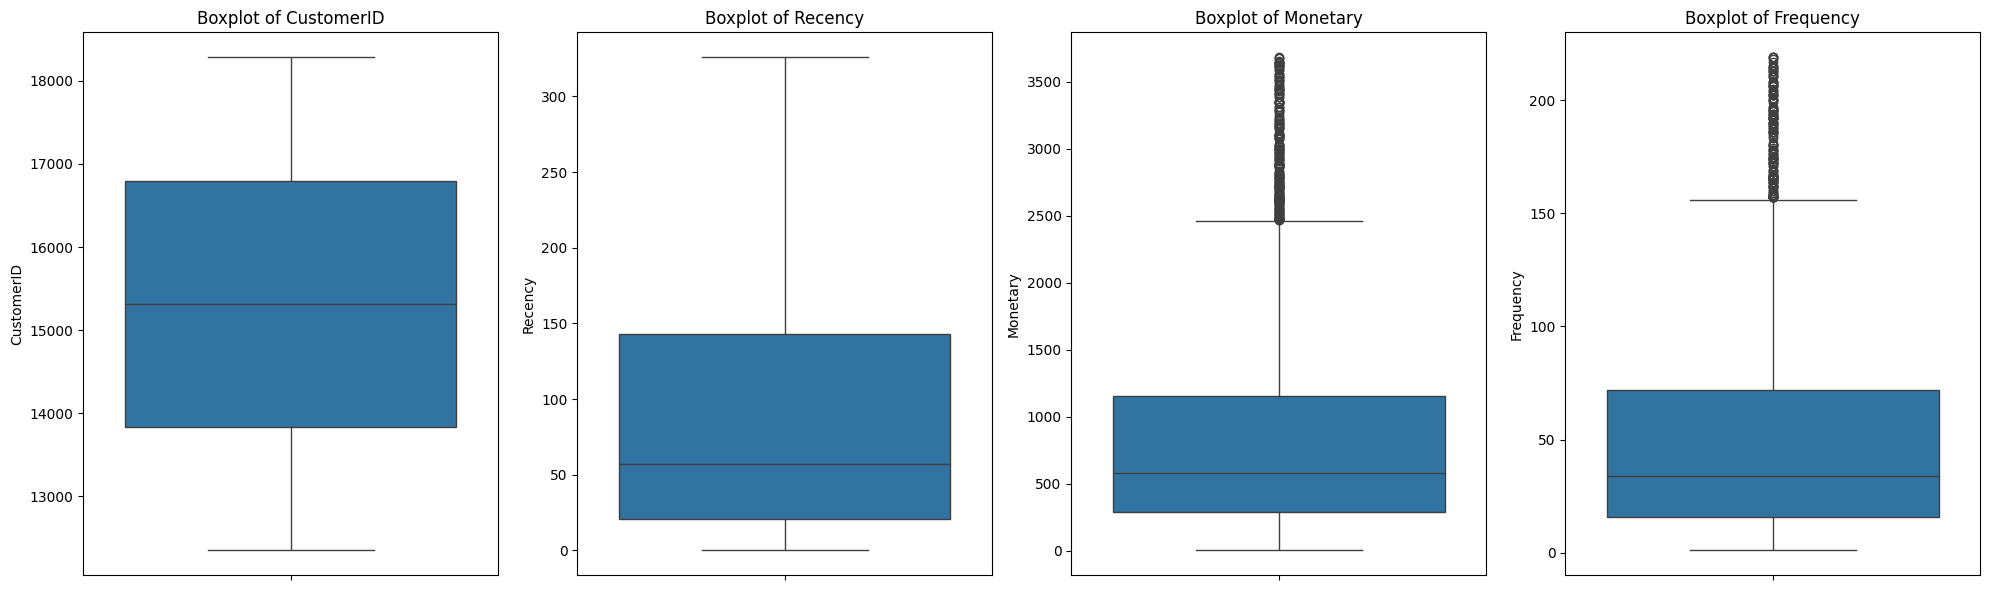

In [ ]:
# Number of columns in the dataset
num_cols = len(rfm_cleaned.columns)

# Create subplots with a dynamic layout
plt.figure(figsize=(5 * num_cols, 6))  # Adjust figure size based on the number of columns
for i, col in enumerate(rfm_cleaned.columns, 1):
    plt.subplot(1, num_cols, i)  # Adjust subplot layout
    sns.boxplot(y=rfm_cleaned[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

In [ ]:
rfm_cleaned.head()

,CustomerID,Recency,Monetary,Frequency
2,12348.0,74,1797.24,31
3,12349.0,18,1757.55,73
4,12350.0,309,334.40,17
5,12352.0,35,2506.04,85
6,12353.0,203,89.00,4


In [ ]:
rfm_cleaned.drop("CustomerID",axis=1,inplace=True)


<ipython-input-78-9efe36732f17>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_cleaned.drop("CustomerID",axis=1,inplace=True)


In [ ]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_cleaned[["Recency","Monetary","Frequency"]])

In [ ]:
rfm_scaled

array([[-0.18912612,  1.20560355, -0.42361668],
       [-0.81531329,  1.15509421,  0.47255691],
       [ 2.4386236 , -0.656001  , -0.72234122],
       ...,
       [ 0.99615673, -0.97870593, -0.93571588],
       [-0.93831434, -0.85497141, -0.82902855],
       [-0.54694736,  1.2565583 ,  0.40854451]])

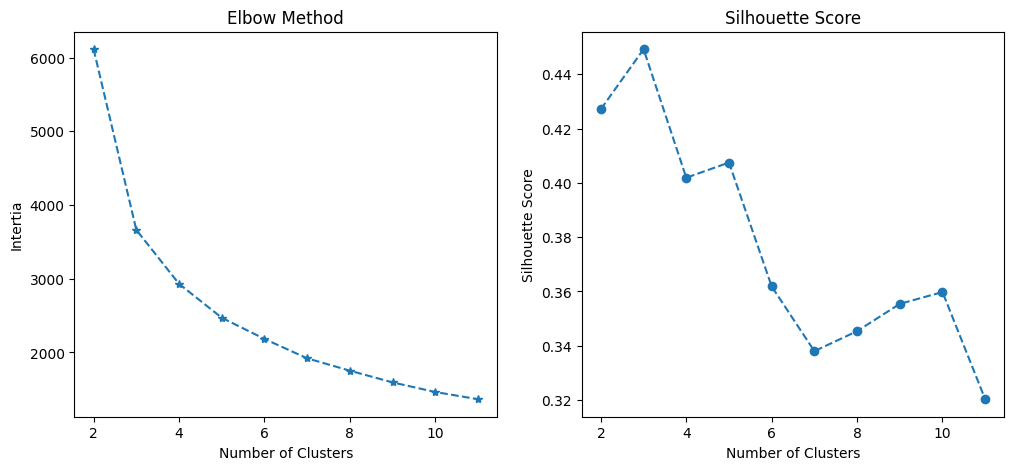

In [ ]:
wss = []
silhouette_scores = []


kRange = range(2,12)
for k in kRange:
  kmeans = KMeans(n_clusters=k,random_state=42, n_init=10)
  kmeans.fit_predict(rfm_scaled)
  wss.append(kmeans.inertia_)
  silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

plt.plot(kRange,wss,marker="*",linestyle="--")
plt.xlabel("Number of Clusters")
plt.ylabel("Intertia")
plt.title("Elbow Method")


plt.subplot(1, 2, 2)

plt.plot(kRange,silhouette_scores,marker="o",linestyle="--")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

if isinstance(rfm_scaled, np.ndarray):
    rfm_scaled = pd.DataFrame(rfm_scaled)

# Now apply clustering and store the results
rfm_scaled["Cluster"] = kmeans.fit_predict(rfm_scaled)


In [ ]:
rfm_scaled.columns = ["Recency", "Frequency", "Monetary", "Cluster"]


In [ ]:
rfm_scaled

,Recency,Frequency,Monetary,Cluster
0,-0.189126,1.205604,-0.423617,0
1,-0.815313,1.155094,0.472557,1
2,2.438624,-0.656001,-0.722341,2
3,-0.625221,2.107620,0.728607,1
4,1.253341,-0.968296,-0.999728,2
...,...,...,...,...
3605,-0.200308,-0.860253,-0.893041,0
3606,2.080802,-0.851726,-0.871703,2
3607,0.996157,-0.978706,-0.935716,2
3608,-0.938314,-0.854971,-0.829029,0


<Axes: xlabel='Frequency', ylabel='Monetary'>

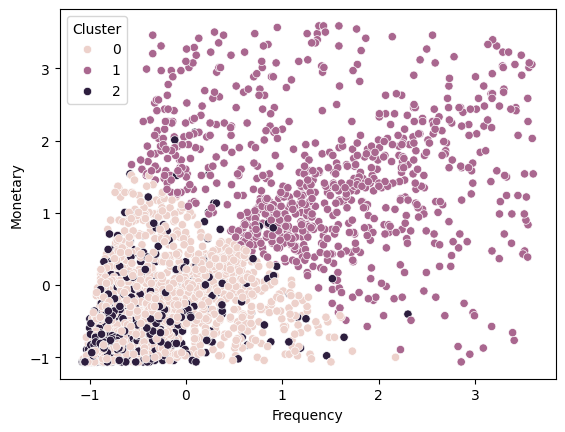

In [ ]:

sns.scatterplot(x="Frequency",y="Monetary",hue="Cluster",data=rfm_scaled,color="viridis")

In [ ]:
rfm_scaled

,Recency,Frequency,Monetary,Cluster
0,-0.189126,1.205604,-0.423617,0
1,-0.815313,1.155094,0.472557,1
2,2.438624,-0.656001,-0.722341,2
3,-0.625221,2.107620,0.728607,1
4,1.253341,-0.968296,-0.999728,2
...,...,...,...,...
3605,-0.200308,-0.860253,-0.893041,0
3606,2.080802,-0.851726,-0.871703,2
3607,0.996157,-0.978706,-0.935716,2
3608,-0.938314,-0.854971,-0.829029,0


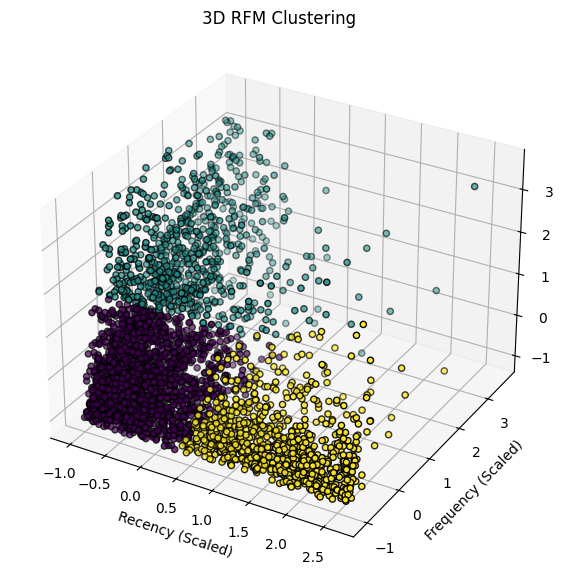

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(
    rfm_scaled.iloc[:, 0],  # Recency
    rfm_scaled.iloc[:, 1],  # Frequency
    rfm_scaled.iloc[:, 2],  # Monetary
    c=rfm_scaled["Cluster"], cmap="viridis", edgecolors="k"
)

# Labels
ax.set_xlabel("Recency (Scaled)")
ax.set_ylabel("Frequency (Scaled)")
ax.set_zlabel("Monetary (Scaled)")
ax.set_title("3D RFM Clustering")

# Show plot
plt.show()


In [ ]:
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(eps=0.5, min_samples=10)  # Tune these values
clusters = dbscan.fit_predict(rfm_scaled)

# Add cluster labels to DataFrame
rfm_scaled["Cluster"] = clusters

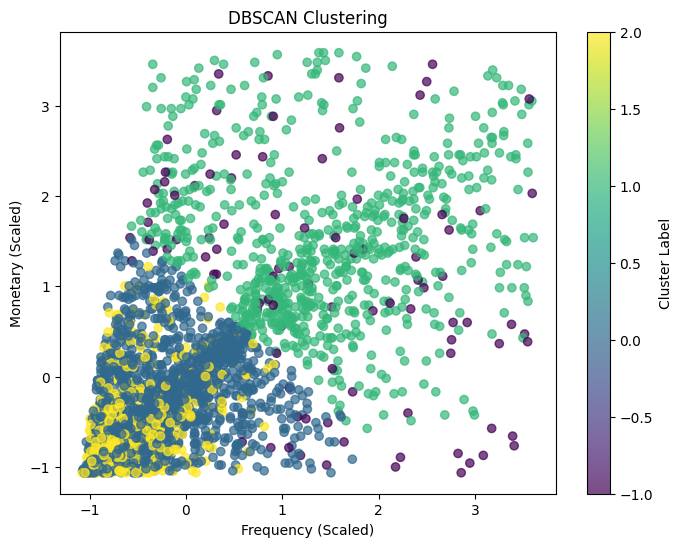

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(rfm_scaled.iloc[:, 1], rfm_scaled.iloc[:, 2], c=clusters, cmap='viridis', alpha=0.7)
plt.xlabel("Frequency (Scaled)")
plt.ylabel("Monetary (Scaled)")
plt.title("DBSCAN Clustering")
plt.colorbar(label="Cluster Label")
plt.show()

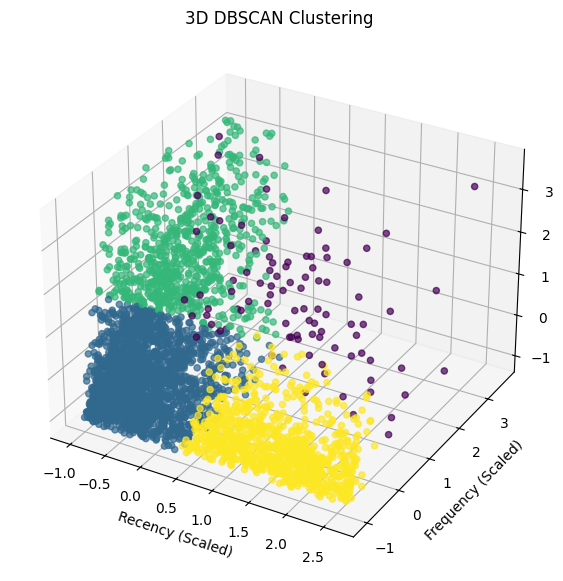

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(rfm_scaled.iloc[:, 0], rfm_scaled.iloc[:, 1], rfm_scaled.iloc[:, 2], c=clusters, cmap='viridis', alpha=0.7)
ax.set_xlabel("Recency (Scaled)")
ax.set_ylabel("Frequency (Scaled)")
ax.set_zlabel("Monetary (Scaled)")
ax.set_title("3D DBSCAN Clustering")
plt.show()


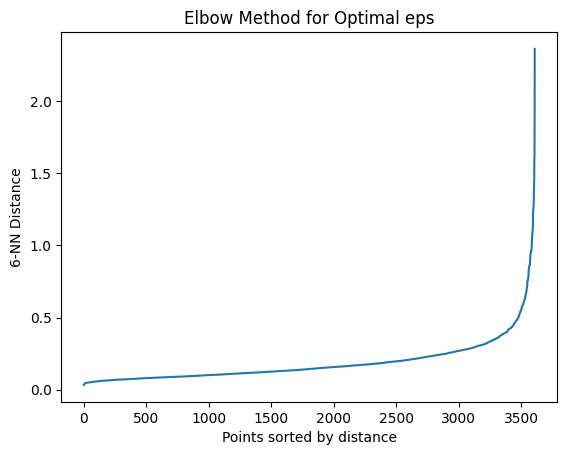

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Select k as min_samples
k = 6  # Adjust this based on dataset size
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(rfm_scaled)
distances, indices = neighbors_fit.kneighbors(rfm_scaled)

# Sort and plot k-distances
distances = np.sort(distances[:, k-1], axis=0)
plt.plot(distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-NN Distance")
plt.title("Elbow Method for Optimal eps")
plt.show()


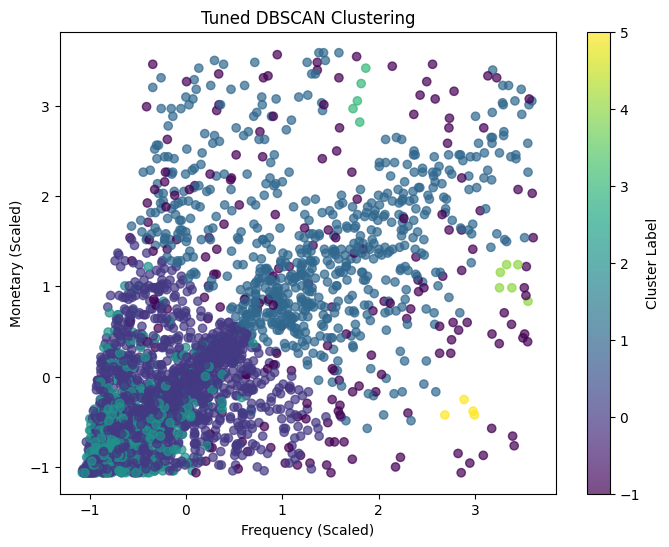

In [ ]:
from sklearn.cluster import DBSCAN

eps_value = 0.5  # Replace with the elbow point value
min_samples_value = 6  # Adjust this for better clusters

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value, metric='manhattan')
clusters = dbscan.fit_predict(rfm_scaled)

# Plot updated clustering
plt.figure(figsize=(8,6))
plt.scatter(rfm_scaled.iloc[:, 1], rfm_scaled.iloc[:, 2], c=clusters, cmap='viridis', alpha=0.7)
plt.xlabel("Frequency (Scaled)")
plt.ylabel("Monetary (Scaled)")
plt.title("Tuned DBSCAN Clustering")
plt.colorbar(label="Cluster Label")
plt.show()


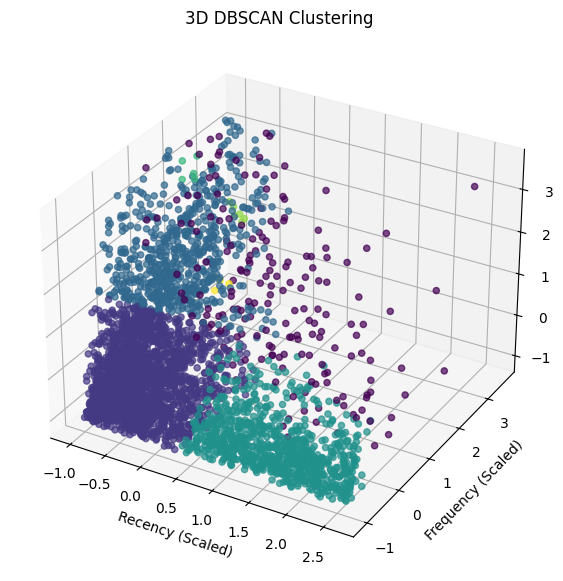

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(rfm_scaled.iloc[:, 0], rfm_scaled.iloc[:, 1], rfm_scaled.iloc[:, 2], c=clusters, cmap='viridis', alpha=0.7)
ax.set_xlabel("Recency (Scaled)")
ax.set_ylabel("Frequency (Scaled)")
ax.set_zlabel("Monetary (Scaled)")
ax.set_title("3D DBSCAN Clustering")
plt.show()


## **Prediction**

In [ ]:
# rfm_scaled['Churn'] = np.where(rfm_cleaned['Recency'] > 90, 1, 0)
rfm_scaled["Churn"] = (rfm_cleaned["Recency"] > 180).astype(int)
rfm_scaled['Churn'].value_counts()

rfm_scaled["Churn"].dropna(inplace=True)
rfm_scaled = rfm_scaled.dropna(subset=["Churn"])  # Remove rows where Churn is NaN
rfm_scaled.isna().sum()

,0
Recency,0
Frequency,0
Monetary,0
Cluster,0
Churn,0


In [ ]:
X = rfm_scaled[["Recency", "Frequency", "Monetary"]]
y = rfm_scaled["Churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_logreg = log_reg.predict(X_test)

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [ ]:
from xgboost import XGBClassifier


xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:58:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
logreg_acc = accuracy_score(y_test, y_pred_logreg)
rf_acc = accuracy_score(y_test, y_pred_rf)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression Accuracy: 0.8073
Random Forest Accuracy: 0.7791
XGBoost Accuracy: 0.7542

Logistic Regression Report:
               precision    recall  f1-score   support

         0.0       0.81      1.00      0.89       486
         1.0       0.00      0.00      0.00       116

    accuracy                           0.81       602
   macro avg       0.40      0.50      0.45       602
weighted avg       0.65      0.81      0.72       602


Random Forest Report:
               precision    recall  f1-score   support

         0.0       0.81      0.95      0.87       486
         1.0       0.19      0.04      0.07       116

    accuracy                           0.78       602
   macro avg       0.50      0.50      0.47       602
weighted avg       0.69      0.78      0.72       602


XGBoost Report:
               precision    recall  f1-score   support

         0.0       0.81      0.92      0.86       486
         1.0       0.18      0.08      0.11       116

    accuracy     

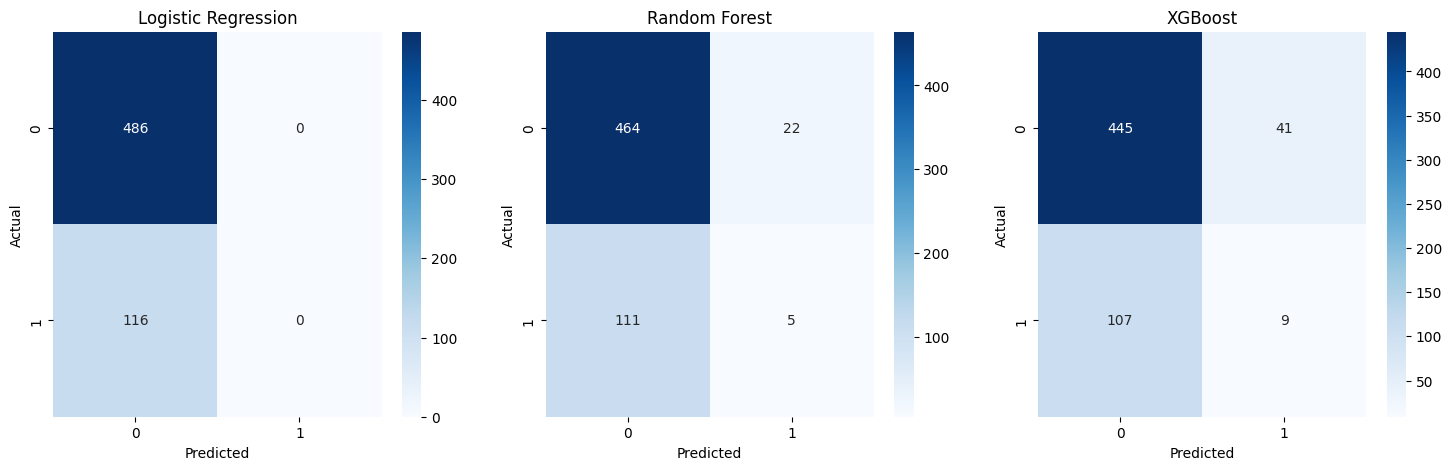

In [ ]:
# Print accuracy scores
print(f"Logistic Regression Accuracy: {logreg_acc:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"XGBoost Accuracy: {xgb_acc:.4f}")

# Print classification reports
print("\nLogistic Regression Report:\n", classification_report(y_test, y_pred_logreg))
print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf))
print("\nXGBoost Report:\n", classification_report(y_test, y_pred_xgb))

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_pred, title in zip(axes, [y_pred_logreg, y_pred_rf, y_pred_xgb],
                              ["Logistic Regression", "Random Forest", "XGBoost"]):
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.show()